# 07 — Possession-Level Baseline

**Frame2Threat v2** | XGBoost on tabular possession features

RQ: Can we predict whether a possession becomes dangerous *at possession onset* — before looking inside the sequence?


## 0. Imports & paths

In [ ]:
import sys, os, warnings
from pathlib import Path

# Robustly find project root whether the kernel cwd is the project root OR notebooks/
_cwd = Path(".").resolve()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import shap
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, RocCurveDisplay,
                             PrecisionRecallDisplay)
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid", palette="muted")
SEED = 42

with open("configs/model_possession.yaml") as f:
    poss_cfg = yaml.safe_load(f)

print(f"Project root: {PROJECT_ROOT}")
print("Ready.")

Project root: C:\Users\USER\Documents\Python Projects\Frame2Threat
Ready.


## 1. Load data

In [22]:
import importlib
import src.features.possession_features as _pf_mod
importlib.reload(_pf_mod)

from src.data.parse_possessions import load_possession_sequences
from src.features.possession_features import build_tabular_features, get_tabular_feature_names
from src.labels.possession_labels import attach_possession_labels

poss = load_possession_sequences("data/processed/possession_sequences.parquet")
print(f"Possessions: {len(poss):,}")

# Attach new possession labels if the parquet pre-dates possession_labels.py
if "poss_tempo" not in poss.columns:
    print("  Attaching new possession labels …")
    poss = attach_possession_labels(poss)

print(f"Feature set: {len(get_tabular_feature_names())} tabular features")
poss.head(3)


Possessions: 17,065
  Attaching new possession labels …
Feature set: 41 tabular features


,match_id,possession_id,team_name,period,origin_type,start_x,start_y,end_x,end_y,max_x_reached,...,event_sequence,poss_xg_generated,poss_has_goal,poss_outcome_tier,poss_tempo,poss_verticality,poss_recycled,poss_phase,poss_broke_pressure,poss_bypassed_lines
0,3764440,1,Barcelona,1,Regular Play,NaN,NaN,NaN,NaN,NaN,...,"[{'type_id': 0, 'loc_x_norm': 0.0, 'loc_y_norm...",NaN,False,0,4.000000,0.000000,False,counter,False,False
1,3764440,2,Elche,1,From Kick Off,61.0,40.099998,89.599998,56.099998,89.599998,...,"[{'type_id': 1, 'loc_x_norm': 0.5083, 'loc_y_n...",NaN,False,1,1.000000,0.063658,True,progression,False,False
2,3764440,3,Barcelona,1,Regular Play,13.4,31.299999,113.599998,44.000000,113.599998,...,"[{'type_id': 0, 'loc_x_norm': 0.1117, 'loc_y_n...",NaN,False,3,0.942308,0.084076,True,build_up,True,False


## 2. Match-level train / val / test split

We reuse the **same 69/15/15 match split** as v1 so results are comparable.

In [23]:
train_ids = pd.read_parquet("data/processed/train.parquet")["match_id"].unique()
val_ids   = pd.read_parquet("data/processed/val.parquet")["match_id"].unique()
test_ids  = pd.read_parquet("data/processed/test.parquet")["match_id"].unique()

train_poss = poss[poss["match_id"].isin(train_ids)].copy()
val_poss   = poss[poss["match_id"].isin(val_ids)].copy()
test_poss  = poss[poss["match_id"].isin(test_ids)].copy()

for name, df in [("train", train_poss), ("val", val_poss), ("test", test_poss)]:
    pos = df["poss_dangerous"].mean()
    print(f"{name:6s}: {len(df):5,} possessions  |  dangerous={pos:.1%}")

train : 12,092 possessions  |  dangerous=32.0%
val   : 2,498 possessions  |  dangerous=33.0%
test  : 2,475 possessions  |  dangerous=36.0%


## 3. EDA
### 3a. Label distribution

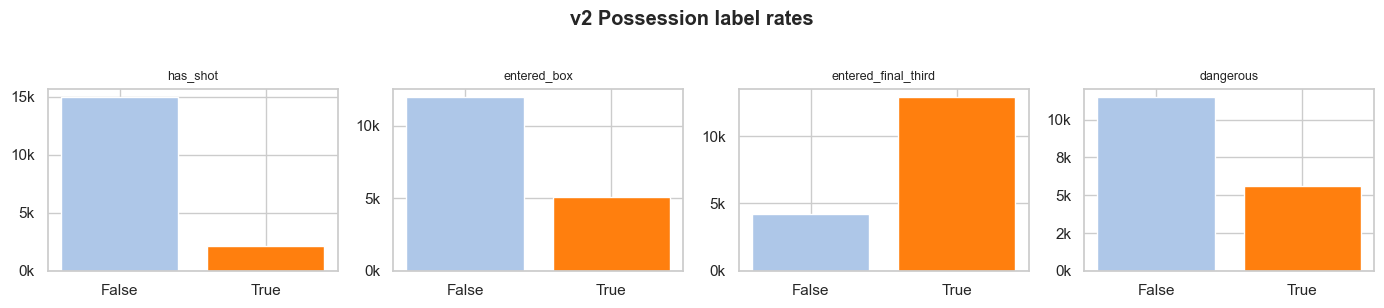

poss_has_shot               12.4%
poss_entered_box            30.0%
poss_entered_final_third    75.4%
poss_dangerous              32.8%
Name: rate, dtype: object


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
label_cols = ["poss_has_shot", "poss_entered_box", "poss_entered_final_third", "poss_dangerous"]
for ax, col in zip(axes, label_cols):
    counts = poss[col].value_counts()
    ax.bar(["False", "True"], [counts.get(False, 0), counts.get(True, 0)],
           color=["#aec7e8", "#ff7f0e"])
    ax.set_title(col.replace("poss_", ""), fontsize=9)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
fig.suptitle("v2 Possession label rates", y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/poss_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(poss[label_cols].mean().rename("rate").map("{:.1%}".format))

### 3b. Key feature distributions

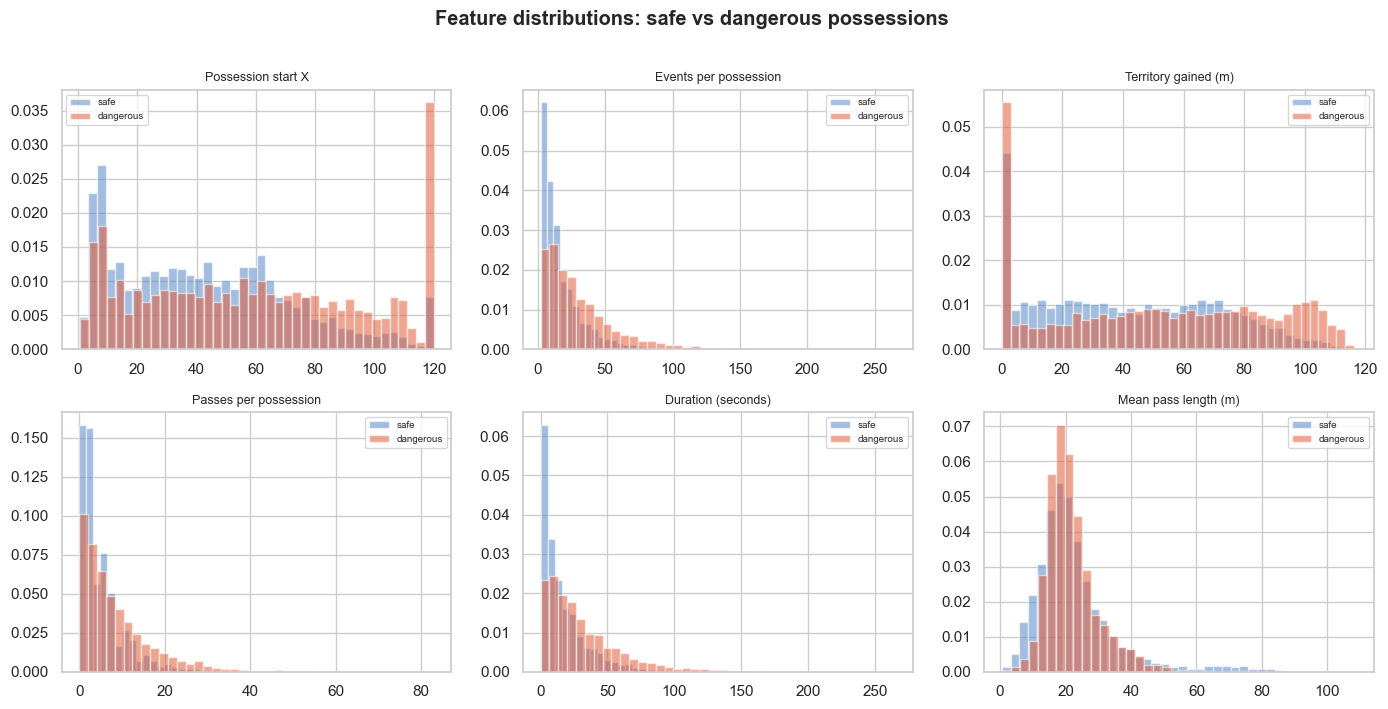

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
feat_pairs = [
    ("start_x",         "Possession start X"),
    ("n_events",        "Events per possession"),
    ("territory_gained","Territory gained (m)"),
    ("n_passes",        "Passes per possession"),
    ("duration_seconds","Duration (seconds)"),
    ("mean_pass_length","Mean pass length (m)"),
]
for ax, (col, title) in zip(axes.flat, feat_pairs):
    dangerous = poss[poss["poss_dangerous"] == True][col].dropna()
    safe      = poss[poss["poss_dangerous"] == False][col].dropna()
    ax.hist(safe,      bins=40, alpha=0.55, label="safe",      density=True, color="#5688c7")
    ax.hist(dangerous, bins=40, alpha=0.55, label="dangerous", density=True, color="#e05e3a")
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Feature distributions: safe vs dangerous possessions", y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/poss_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 3c. Origin type breakdown

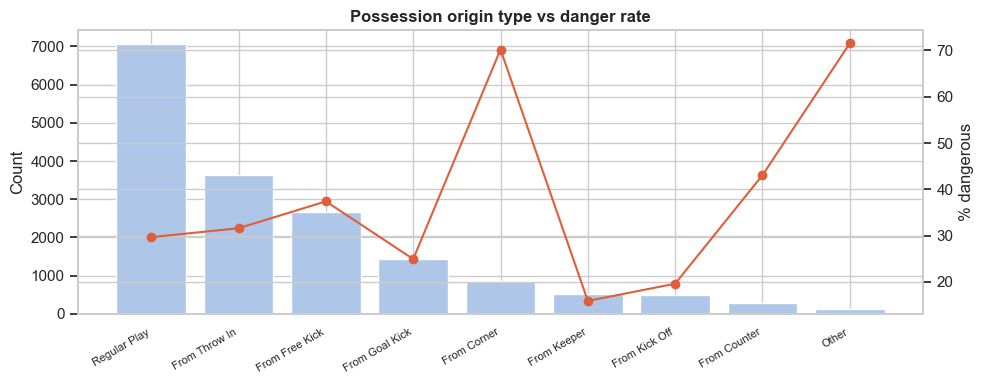

poss_dangerous  total  dangerous_rate
origin_type                          
Regular Play     7066        0.296773
From Throw In    3632        0.316079
From Free Kick   2673        0.374111
From Goal Kick   1423        0.249473
From Corner       856        0.702103
From Keeper       522        0.159004
From Kick Off     489        0.196319
From Counter      281        0.430605
Other             123        0.715447


In [6]:
origin_counts = poss.groupby(["origin_type", "poss_dangerous"]).size().unstack(fill_value=0)
origin_counts["total"] = origin_counts.sum(axis=1)
origin_counts["dangerous_rate"] = origin_counts.get(True, 0) / origin_counts["total"]
origin_counts = origin_counts.sort_values("total", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(origin_counts))
ax.bar(x, origin_counts["total"], color="#aec7e8", label="total")
ax2 = ax.twinx()
ax2.plot(x, origin_counts["dangerous_rate"] * 100, "o-", color="#e05e3a", label="% dangerous")
ax.set_xticks(x)
ax.set_xticklabels(origin_counts.index, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Count")
ax2.set_ylabel("% dangerous")
ax.set_title("Possession origin type vs danger rate", fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/poss_origin_danger.png", dpi=150, bbox_inches="tight")
plt.show()
print(origin_counts[["total", "dangerous_rate"]].to_string())

## 4. Feature matrix

In [24]:
LABEL = "poss_dangerous"

X_train = build_tabular_features(train_poss)
y_train = train_poss[LABEL].astype(int)

X_val   = build_tabular_features(val_poss)
y_val   = val_poss[LABEL].astype(int)

X_test  = build_tabular_features(test_poss)
y_test  = test_poss[LABEL].astype(int)

print(f"Train:  X={X_train.shape}  pos={y_train.mean():.1%}")
print(f"Val:    X={X_val.shape}  pos={y_val.mean():.1%}")
print(f"Test:   X={X_test.shape}  pos={y_test.mean():.1%}")
print(f"NaN counts — train: {X_train.isna().sum().sum()}  val: {X_val.isna().sum().sum()}  test: {X_test.isna().sum().sum()}")

Train:  X=(12092, 41)  pos=32.0%
Val:    X=(2498, 41)  pos=33.0%
Test:   X=(2475, 41)  pos=36.0%
NaN counts — train: 483  val: 105  test: 105


## 5. XGBoost baseline

In [ ]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
_xgb_cfg = poss_cfg["xgboost_main"]

model = XGBClassifier(
    n_estimators=_xgb_cfg["n_estimators"],
    max_depth=_xgb_cfg["max_depth"],
    learning_rate=_xgb_cfg["learning_rate"],
    subsample=_xgb_cfg["subsample"],
    colsample_bytree=_xgb_cfg["colsample_bytree"],
    scale_pos_weight=scale_pos,
    eval_metric=_xgb_cfg["eval_metric"],
    early_stopping_rounds=_xgb_cfg["early_stopping_rounds"],
    random_state=_xgb_cfg["random_state"],
    n_jobs=_xgb_cfg["n_jobs"],
    verbosity=0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Best round: {model.best_iteration}")
val_proba = model.predict_proba(X_val)[:, 1]
print(f"Val ROC-AUC : {roc_auc_score(y_val, val_proba):.4f}")
print(f"Val AP      : {average_precision_score(y_val, val_proba):.4f}")

Best round: 216
Val ROC-AUC : 0.9509
Val AP      : 0.8823


## 6. Test set evaluation

Test ROC-AUC : 0.9505
Test AP      : 0.8947

              precision    recall  f1-score   support

        safe       0.97      0.84      0.90      1584
   dangerous       0.78      0.96      0.86       891

    accuracy                           0.88      2475
   macro avg       0.87      0.90      0.88      2475
weighted avg       0.90      0.88      0.89      2475



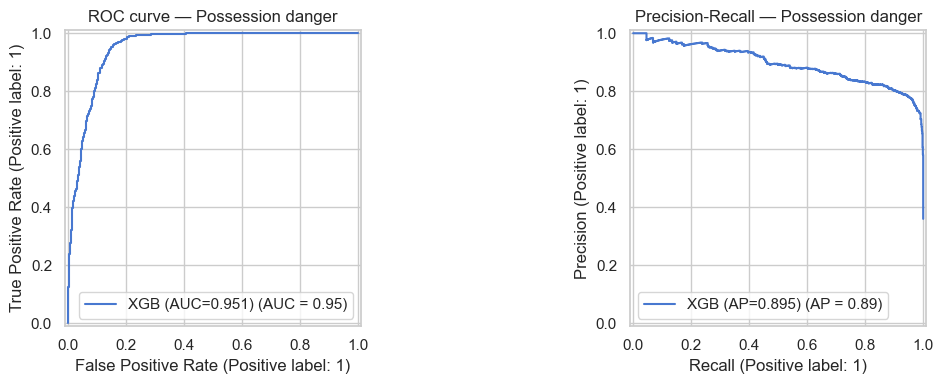

In [26]:
test_proba = model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, test_proba)
ap      = average_precision_score(y_test, test_proba)

print(f"Test ROC-AUC : {roc_auc:.4f}")
print(f"Test AP      : {ap:.4f}")
print()
print(classification_report(y_test, test_pred, target_names=["safe", "dangerous"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, test_proba, ax=ax1, name=f"XGB (AUC={roc_auc:.3f})")
PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=ax2, name=f"XGB (AP={ap:.3f})")
ax1.set_title("ROC curve — Possession danger")
ax2.set_title("Precision-Recall — Possession danger")
plt.tight_layout()
plt.savefig("reports/figures/poss_baseline_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Calibration

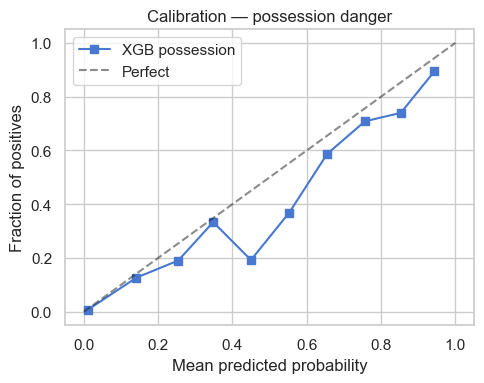

In [10]:
prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(prob_pred, prob_true, "s-", label="XGB possession")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration — possession danger")
ax.legend()
plt.tight_layout()
plt.savefig("reports/figures/poss_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. SHAP feature importance

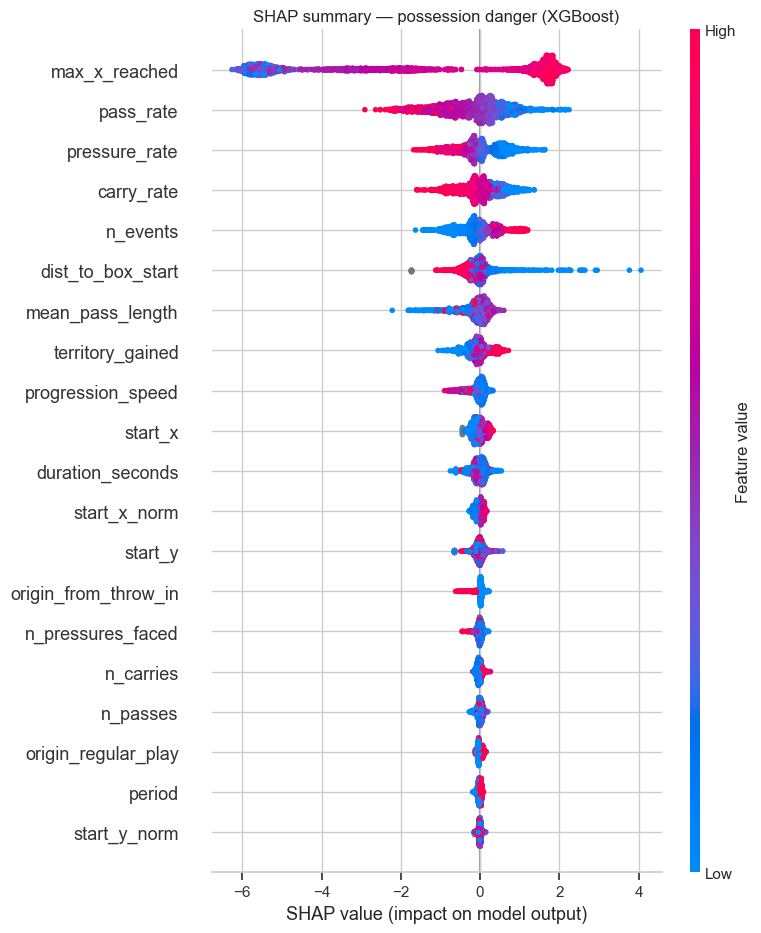

In [11]:
explainer    = shap.TreeExplainer(model)
shap_values  = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title("SHAP summary — possession danger (XGBoost)")
plt.tight_layout()
plt.savefig("reports/figures/poss_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

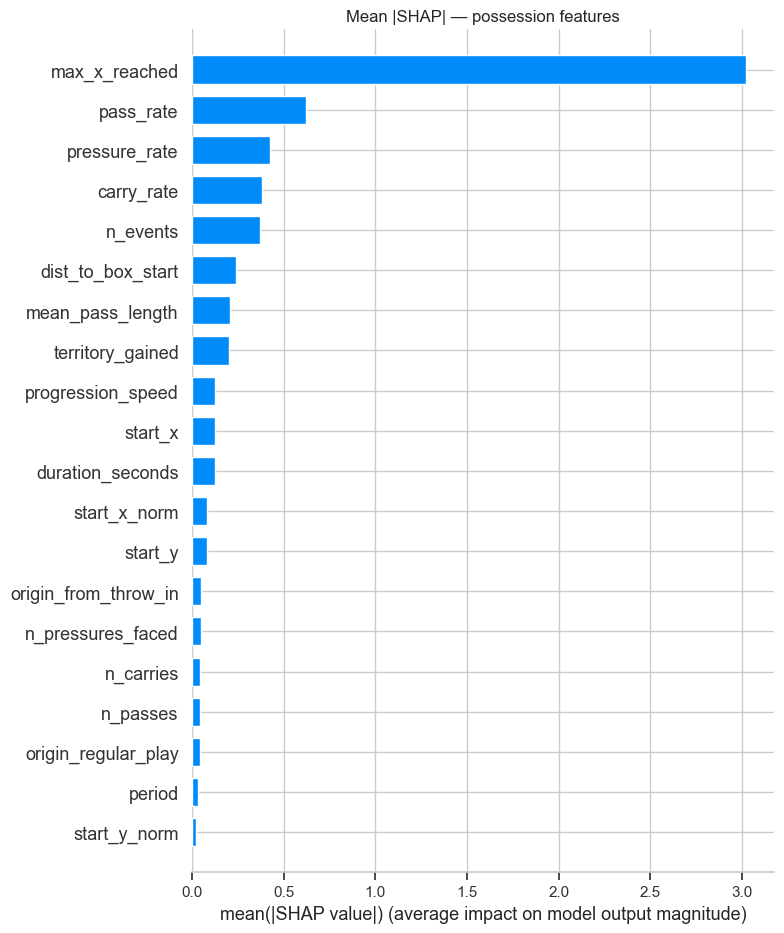

In [12]:
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.title("Mean |SHAP| — possession features")
plt.tight_layout()
plt.show()

## 9. Compare with v1 pass-level model

| Model | Unit | Test ROC-AUC | Notes |
|---|---|---|---|
| XGBoost (event+360) | pass | 0.881 | v1 gold standard |
| XGBoost (event only) | pass | 0.880 | v1 event-only |
| **XGBoost (tabular)** | **possession** | **—** | **v2 baseline** |

In [13]:
# Fill in the v2 result
v2_auc = roc_auc_score(y_test, test_proba)
print(f"v2 XGBoost possession baseline — Test ROC-AUC: {v2_auc:.4f}")
print()
print("Comparison:")
print(f"  v1 pass-level (event+360) : 0.881")
print(f"  v1 pass-level (event only): 0.880")
print(f"  v2 possession  (tabular)  : {v2_auc:.3f}")
print()
print("Note: AUC not directly comparable — different prediction units & class balance.")
print(f"v1 positive rate: ~51% | v2 positive rate (poss_dangerous): {y_test.mean():.1%}")

v2 XGBoost possession baseline — Test ROC-AUC: 0.9479

Comparison:
  v1 pass-level (event+360) : 0.881
  v1 pass-level (event only): 0.880
  v2 possession  (tabular)  : 0.948

Note: AUC not directly comparable — different prediction units & class balance.
v1 positive rate: ~51% | v2 positive rate (poss_dangerous): 36.0%


## 10. Save artefact

In [27]:
import json, os
from pathlib import Path

Path("models").mkdir(exist_ok=True)
outpath = "models/xgboost_poss_dangerous.joblib"
joblib.dump(model, outpath)
print(f"Saved → {outpath}")

# Append to results summary
results_path = "models/results_summary.json"
if Path(results_path).exists():
    with open(results_path) as f:
        results = json.load(f)
else:
    results = {}

results["xgboost_poss_dangerous"] = {
    "model": "XGBClassifier",
    "unit": "possession",
    "label": "poss_dangerous",
    "n_features": X_test.shape[1],
    "n_train": len(X_train),
    "n_val": len(X_val),
    "n_test": len(X_test),
    "val_roc_auc": round(roc_auc_score(y_val,  model.predict_proba(X_val)[:,1]), 4),
    "test_roc_auc": round(roc_auc, 4),
    "test_ap": round(ap, 4),
}

with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print("results_summary.json updated.")

Saved → models/xgboost_poss_dangerous.joblib
results_summary.json updated.
